# Ovrlpy applied to vizgen receptor data map



In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import ovrlpy
import pandas as pd
import tqdm
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Polygon

/dh-projects/ag-ishaque/analysis/muellni/envs/ovrlpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

import matplotlib

sys.path.append("../..")

from utils import CM, FONT, plot_doublet, save_kwargs

matplotlib.rc("font", **FONT)

In [3]:
n_slice = 2


data_dir = Path(
    f"/dh-projects/ag-ishaque/raw_data/vizgen-merfish/vz-receptor-showcase/Slice{n_slice}/Replicate1"
)
boundaries_path = data_dir / "cell_boundaries"
coordinate_path = "../detected_transcripts.parquet"

In [4]:
import pickle

with open("../merscope_brain.pickle", "rb") as file:
    brain = pickle.load(file)

coordinate_df = brain.transcripts

signal_integrity = brain.integrity_map
signal_strength = brain.signal_map

In [5]:
doublet_df = brain.detect_doublets(min_signal=3, integrity_sigma=2)

In [6]:
polygons = [[] for i in range(7)]

n_cell = 0
cell_ids_map = {}

boundaries = []

files = sorted(boundaries_path.iterdir())

for file in tqdm.tqdm(files, total=len(files)):
    with h5py.File(file, "r") as f:
        for cell, cell_idxs in f["featuredata"].items():
            if cell not in cell_ids_map:
                cell_ids_map[cell] = n_cell
                n_cell += 1
            cell_id = cell_ids_map[cell]
            for idx_key, idx in cell_idxs.items():
                if isinstance(idx, h5py.Dataset):
                    continue
                else:
                    idx_key_layer = int(idx_key.split("_")[-1])
                    if "p_0" in idx.keys():
                        coord = idx["p_0"]["coordinates"][0]

                        polygons[idx_key_layer].append((Polygon(coord), cell_id))

                        boundaries.append(pd.DataFrame(coord, columns=["x", "y"]))
                        boundaries[-1]["cell_id"] = cell_id
                        boundaries[-1]["z_index"] = idx_key_layer

boundary_df = pd.concat(boundaries)

del boundaries

100%|██████████| 1242/1242 [14:54<00:00,  1.39it/s] 


In [11]:
origin = ovrlpy.io.read_MERSCOPE(coordinate_path).select(("x", "y")).min()

boundary_df["x"] -= origin["x"][0]
boundary_df["y"] -= origin["y"][0]

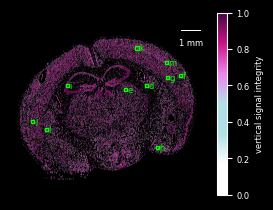

In [12]:
alphabet = "abcdefghijklmnopqrstuvwxyz"

fig = ovrlpy.plot_signal_integrity(
    brain,
    histogram=False,
    scalebar={"dx": 1, "units": "um", "frameon": False, "color": "w"},
    figsize=(8 * CM, 6 * CM),
)

ax = fig.axes[0]

ax.invert_yaxis()
ax.invert_xaxis()
ax.axis("off")


for i in range(10):
    x, y = doublet_df["x", "y"].row(i)
    ax.text(x - 100, y, alphabet[i + 3], fontsize=6, color="lime", va="center")
    ax.scatter(x, y, marker="s", s=5, edgecolors="lime", facecolors="None", lw=1)


fig.savefig("receptor_integrity.svg", **save_kwargs)

In [13]:
def plot_outlines(df, x, y, window_size, ax):
    x_, _x = x - window_size, x + window_size
    y_, _y = y - window_size, y + window_size

    subset = df[df["x"].between(x_, _x) & df["y"].between(y_, _y)].copy()
    subset["x"] -= x_
    subset["y"] -= y_

    for i, (_, cell) in enumerate(subset.groupby("cell_id", observed=True)):
        # cell_center = cell[["x", "y"]].mean()
        # _ = ax.text(
        #     cell_center["x"],
        #     cell_center["y"],
        #     f"{i + 1}",
        #     fontsize=6,
        #     color=colors[i % len(colors)],
        # )

        for _, cell_z in cell.groupby("z_index", observed=True):
            ax.plot(cell_z["x"], cell_z["y"], c=colors[i % len(colors)], lw=1)

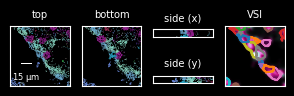

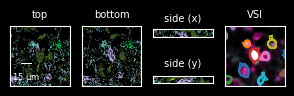

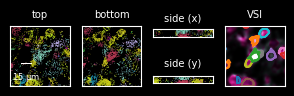

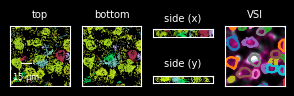

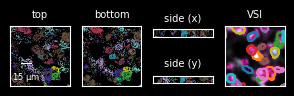

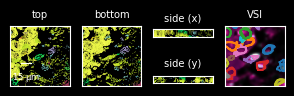

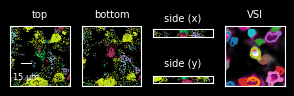

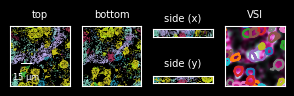

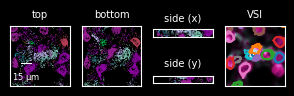

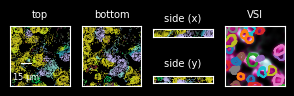

In [14]:
window_size = 40

prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]

with plt.style.context("dark_background"):
    for i in range(10):
        x, y = doublet_df["x", "y"].row(i)

        fig = plot_doublet(
            brain,
            x,
            y,
            window_size=window_size,
            signal_threshold=2,
            figsize=(9 * CM, 2.8 * CM),
        )

        for j in range(4):
            fig.axes[j].collections[0].set_rasterized(True)

        ax = fig.axes[4]
        plot_outlines(boundary_df, x, y, window_size, ax)

        fig.axes[0].add_artist(
            ScaleBar(
                1,
                units="um",
                length_fraction=0.2,
                loc="lower left",
                frameon=False,
                color="w",
            )
        )

        fig.savefig(f"receptor_doublet_{i + 1}_segments.svg", **save_kwargs)